In [42]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import os
from scipy.interpolate import interp1d
from scipy.signal import savgol_filter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.19.0


In [43]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/mohamedeidshehata6/c-grain/C_Grain_dataset.csv")  # أو read_excel لو xlsx

# أسماء الأعمدة
print("Columns:", df.columns.tolist())

# أول 5 صفوف في time و thrust
print(df[['Time (s)', 'Thrust (N)']].head())  # غيّر أسماء الأعمدة لو مختلفة

# فحص الـ noise
print("\nBasic Stats:")
print(df.describe())

print("\nMissing values:")
print(df.isnull().sum())

Columns: ['Time (s)', 'Pressure (MPa)', 'Thrust (N)', 'ID', 'Length', 'Diameter', 'Slot_Width', 'Slot_Offset', 'Throat_Diameter', 'Exit_Diameter', 'Total Impulse (Ns)', 'ISP (s)', 'Max Thrust (N)', 'Peak Pressure (MPa)', 'Burn Time (s)', 'Avg Thrust (N)']
   Time (s)  Thrust (N)
0     0.000      0.0000
1     0.005    151.9416
2     0.010    152.2069
3     0.015    152.4727
4     0.020    152.7388

Basic Stats:
           Time (s)  Pressure (MPa)    Thrust (N)            ID        Length  \
count  1.492858e+07    1.492858e+07  1.492858e+07  1.492858e+07  1.492858e+07   
mean   9.205208e+00    9.734344e+00  2.303226e+03  2.230939e+03  5.946290e+01   
std    6.438885e+00    1.086140e+01  2.311439e+03  1.307284e+03  2.405937e+01   
min    0.000000e+00    1.492000e-01  0.000000e+00  1.000000e+00  2.000000e+01   
25%    4.045000e+00    3.546500e+00  7.415787e+02  1.110000e+03  4.000000e+01   
50%    8.160000e+00    6.898400e+00  1.644127e+03  2.232000e+03  6.000000e+01   
75%    1.316000e+01

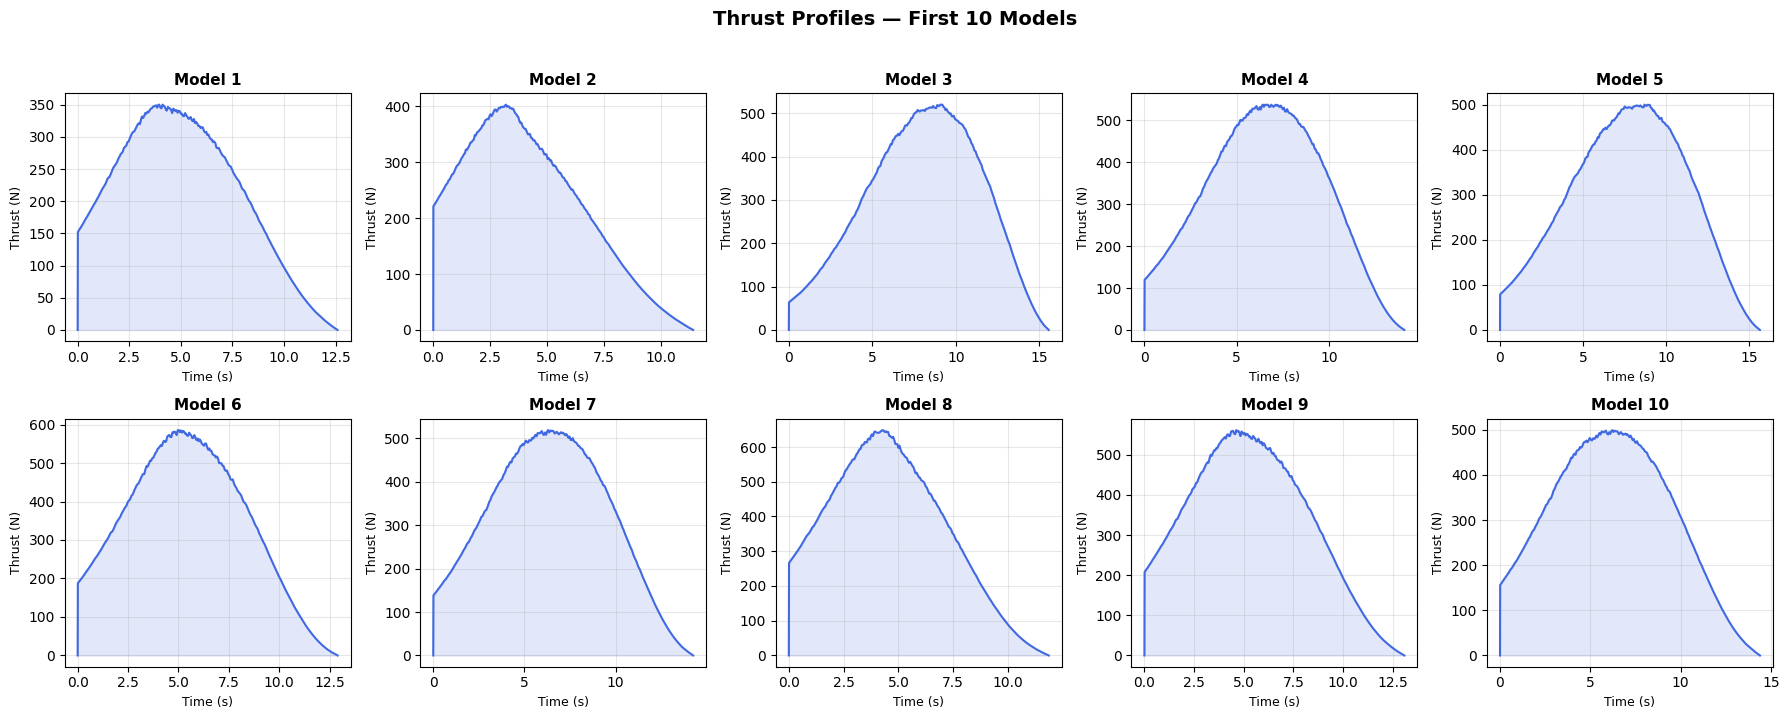

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/kaggle/input/datasets/mohamedeidshehata6/c-grain/C_Grain_dataset.csv")  # غيّر الاسم

# أول 10 Model_IDs
first_10_models = sorted(df['ID'].unique())[:10]
df_10 = df[df['ID'].isin(first_10_models)]

# الرسم
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

for i, model_id in enumerate(first_10_models):
    model_data = df_10[df_10['ID'] == model_id]
    
    axes[i].plot(model_data['Time (s)'], model_data['Thrust (N)'], 
                 color='royalblue', linewidth=1.5)
    axes[i].set_title(f'Model {int(model_id)}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Time (s)', fontsize=9)
    axes[i].set_ylabel('Thrust (N)', fontsize=9)
    axes[i].grid(True, alpha=0.3)
    axes[i].fill_between(model_data['Time (s)'], model_data['Thrust (N)'], 
                          alpha=0.15, color='royalblue')

plt.suptitle('Thrust Profiles — First 10 Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
# plt.savefig('thrust_profiles.png', dpi=150, bbox_inches='tight')
plt.show()
# print("✅ تم الحفظ: thrust_profiles.png")

In [54]:
def process_c_data(file_path, num_points=100):
    if not os.path.exists(file_path): 
        raise FileNotFoundError(f'File not found: {file_path}')
        
    # قراءة الملف وتجاوز الأخطاء
    df = pd.read_csv(file_path, on_bad_lines='skip', skip_blank_lines=True)
    df.columns = df.columns.str.strip()
    df['ID'] = pd.to_numeric(df['ID'], errors='coerce')
    
    ids = df['ID'].unique()
    X, y_thrust, y_pressure, y_scalars = [], [], [], []

    # أسماء الأعمدة الـ 6 للـ C Grain
    input_cols = ['Length', 'Diameter', 'Slot_Width', 'Slot_Offset', 'Throat_Diameter', 'Exit_Diameter']

    for uid in ids:
        try:
            case_data = df[df['ID'] == uid].sort_values('Time (s)')
            
            # سحب الأبعاد الستة
            inputs = case_data[input_cols].iloc[0].values
            t = case_data['Time (s)'].values
            
            if len(t) < 2 or t[-1] <= 0 or np.any(inputs <= 0): 
                continue

            thrust = case_data['Thrust (N)'].fillna(0).values
            pressure = case_data['Pressure (MPa)'].fillna(0).values

            # تنعيم المنحنيات
            #if len(thrust) > 7:
                #thrust = savgol_filter(thrust, window_length=7, polyorder=3)
                #pressure = savgol_filter(pressure, window_length=7, polyorder=3)

            # توحيد طول المنحنيات لـ 100 نقطة
            x_new = np.linspace(t[0], t[-1], num_points)
            X.append(inputs)
            y_thrust.append(interp1d(t, thrust, kind='linear', fill_value='extrapolate')(x_new))
            y_pressure.append(interp1d(t, pressure, kind='linear', fill_value='extrapolate')(x_new))
            
            # سحب القيم الثابتة (ISP, Total Impulse, Burn Time, Max Thrust)
            y_scalars.append([
                case_data['ISP (s)'].iloc[0], 
                #case_data['Total Impulse (Ns)'].iloc[0], 
                t[-1], 
                #np.max(thrust)
            ])
            
        except Exception: 
            continue
        
    return np.array(X), np.array(y_thrust), np.array(y_pressure), np.array(y_scalars)

# ==========================================
# استدعاء ملف الـ CSV الخاص بـ Moon Grain
# ==========================================
file_path = '/kaggle/input/datasets/mohamedeidshehata6/c-grain/C_Grain_dataset.csv' # ضع المسار الصحيح هنا
X, yt, yp, ys = process_c_data(file_path) 
X, yt, yp, ys = X.astype(float), yt.astype(float), yp.astype(float), ys.astype(float)

# توحيد الأطوال لتجنب أي أخطاء
min_s = min(len(X), len(yt), len(yp), len(ys))
X, yt, yp, ys = X[:min_s], yt[:min_s], yp[:min_s], ys[:min_s]

print(f"✅ C Data loaded successfully: {len(X)} cases.")
print(f"Input shape (X): {X.shape}") # يجب أن يكون (N, 6)

✅ C Data loaded successfully: 4613 cases.
Input shape (X): (4613, 6)


In [55]:
# تقسيم البيانات
X_train, X_test, yt_train, yt_test, yp_train, yp_test, ys_train, ys_test = train_test_split(
    X, yt, yp, ys, test_size=0.15, random_state=42
)

from sklearn.preprocessing import MinMaxScaler
import joblib

# 1. تقييس الأبعاد (المدخلات)
s_X = MinMaxScaler()
X_tr_s = s_X.fit_transform(X_train)
X_te_s = s_X.transform(X_test)

# 2. الخدعة الفيزيائية (Global Max Scaling للمنحنيات)
# هذا يحافظ على القمم الحادة للـ Moon Burner ولا يشوهها
yt_max = np.max(yt_train)
yp_max = np.max(yp_train)

yt_tr_s = yt_train / yt_max
yt_te_s = yt_test / yt_max

yp_tr_s = yp_train / yp_max
yp_te_s = yp_test / yp_max

# 3. تقييس القيم الثابتة
s_ys = MinMaxScaler()
ys_tr_s = s_ys.fit_transform(ys_train)
ys_te_s = s_ys.transform(ys_test)

# حفظ المقاييس الجديدة
joblib.dump(s_X, 'co_fwd_scaler_X.pkl')
joblib.dump(s_ys, 'co_fwd_scaler_scalars.pkl')
joblib.dump({'yt_max': yt_max, 'yp_max': yp_max}, 'co_fwd_max_values.pkl')

print("✅ Smart Physical Scaling Applied!")

✅ Smart Physical Scaling Applied!


In [56]:
from tensorflow.keras.layers import RepeatVector, TimeDistributed, GRU, Flatten

def build_c_forward_model_gru():
    inputs = layers.Input(shape=(6,), name='Co_Dimensions_Input')

    # 1. استخراج الخصائص الهندسية (Encoder)
    x = layers.Dense(128, activation='elu')(inputs)
    x = layers.Dense(256, activation='elu')(x)
    latent_vector = layers.Dense(64, activation='elu')(x)

    # 2. تحويل الأبعاد إلى تسلسل زمني (Vector to Sequence)
    # تكرار الخصائص 100 مرة لتمهيد الطريق لشبكات الذاكرة
    seq_input = RepeatVector(100)(latent_vector)

    # 3. مسار منحنى الدفع (استخدام GRU)
    # الـ GRU سيفهم التتابع الزمني ويرسم خط الثبات (Plateau) بنعومة فائقة
    b_t = GRU(128, return_sequences=True, activation='tanh')(seq_input)
    b_t = GRU(64, return_sequences=True, activation='tanh')(b_t)
    out_t_seq = TimeDistributed(layers.Dense(1, activation='linear'))(b_t)
    out_thrust = Flatten(name='Thrust_Output')(out_t_seq) # إعادتها لشكل 100 نقطة

    # 4. مسار منحنى الضغط (استخدام GRU)
    b_p = GRU(128, return_sequences=True, activation='tanh')(seq_input)
    b_p = GRU(64, return_sequences=True, activation='tanh')(b_p)
    out_p_seq = TimeDistributed(layers.Dense(1, activation='linear'))(b_p)
    out_pressure = Flatten(name='Pressure_Output')(out_p_seq)

    # 5. مسار القيم الثابتة (يظل Dense لأنه لا يحتاج زمناً)
    b_s = layers.Dense(32, activation='elu')(latent_vector)
    out_scalars = layers.Dense(2, activation='linear', name='Scalars_Output')(b_s)

    model = Model(inputs=inputs, outputs=[out_thrust, out_pressure, out_scalars])
    
    # استخدام MSE مع الـ GRU يعطي نتائج استثنائية في المنحنيات
    #model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    model.compile(
    optimizer=Adam(learning_rate=0.0003),

    loss={
        'Thrust_Output': 'mse',
        'Pressure_Output': 'mse',
        'Scalars_Output': 'mse'
    },

    loss_weights={
        'Thrust_Output': 1.0,
        'Pressure_Output': 1.0,
        'Scalars_Output': 4.0
    }
)
    
    return model

moon_forward = build_c_forward_model_gru()
moon_forward.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Co_Dimensions_Input │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 128)       │        896 │ Co_Dimensions_In… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_19 (Dense)    │ (None, 256)       │     33,024 │ dense_18[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_20 (Dense)    │ (None, 64)        │     16,448 │ dense_19[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector_3     │ (None, 100, 64)   │          0 │ dense_20[0][0]    │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_12 (GRU)        │ (None, 100, 128)  │     74,496 │ repeat_vector_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_14 (GRU)        │ (None, 100, 128)  │     74,496 │ repeat_vector_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_13 (GRU)        │ (None, 100, 64)   │     37,248 │ gru_12[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_15 (GRU)        │ (None, 100, 64)   │     37,248 │ gru_14[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_6  │ (None, 100, 1)    │         65 │ gru_13[0][0]      │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_7  │ (None, 100, 1)    │         65 │ gru_15[0][0]      │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_23 (Dense)    │ (None, 32)        │      2,080 │ dense_20[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Thrust_Output       │ (None, 100)       │          0 │ time_distributed… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Pressure_Output     │ (None, 100)       │          0 │ time_distributed… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Scalars_Output      │ (None, 2)         │         66 │ dense_23[0][0]    │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 276,132 (1.05 MB)

 Trainable params: 276,132 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

In [57]:
# إعداد متحكمات التدريب
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-5, verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=40, restore_best_weights=True, verbose=1)

print("Starting training for Moon Forward Model...")
history_fwd = moon_forward.fit(
    x=X_tr_s, 
    y={'Thrust_Output': yt_tr_s, 'Pressure_Output': yp_tr_s, 'Scalars_Output': ys_tr_s},
    validation_split=0.15,
    epochs=400,
    batch_size=64,
    callbacks=[early_stopping, lr_scheduler],
    verbose=1
)


Starting training for Moon Forward Model...
Epoch 1/400
53/53 ━━━━━━━━━━━━━━━━━━━━ 15s 82ms/step - Pressure_Output_loss: 0.0072 - Scalars_Output_loss: 0.0584 - Thrust_Output_loss: 0.0102 - loss: 0.2511 - val_Pressure_Output_loss: 0.0033 - val_Scalars_Output_loss: 0.0061 - val_Thrust_Output_loss: 0.0094 - val_loss: 0.0364 - learning_rate: 3.0000e-04
Epoch 2/400
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - Pressure_Output_loss: 0.0030 - Scalars_Output_loss: 0.0062 - Thrust_Output_loss: 0.0083 - loss: 0.0360 - val_Pressure_Output_loss: 0.0031 - val_Scalars_Output_loss: 0.0060 - val_Thrust_Output_loss: 0.0084 - val_loss: 0.0350 - learning_rate: 3.0000e-04
Epoch 3/400
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - Pressure_Output_loss: 0.0030 - Scalars_Output_loss: 0.0062 - Thrust_Output_loss: 0.0083 - loss: 0.0362 - val_Pressure_Output_loss: 0.0031 - val_Scalars_Output_loss: 0.0056 - val_Thrust_Output_loss: 0.0083 - val_loss: 0.0333 - learning_rate: 3.0000e-04
Epoch 4/400
53/53 ━━━━━━━━━━━━━━━━━━━

In [58]:
# حفظ الموديل
moon_forward.save('Co_Forward_Model.keras')
print("\n✅ Co Forward Model trained and saved successfully.")


✅ Co Forward Model trained and saved successfully.


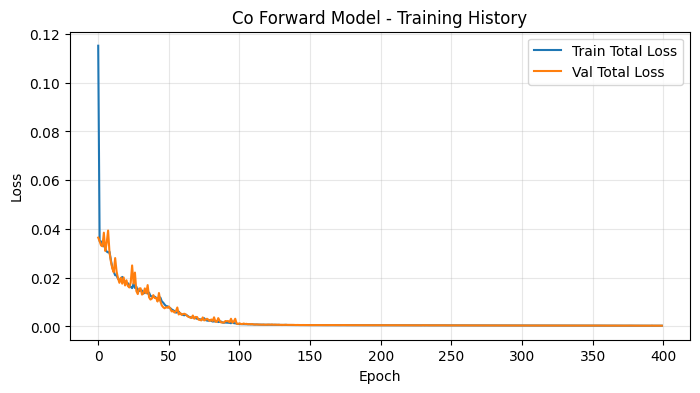

In [59]:
# رسم منحنى التعلّم الكلي
plt.figure(figsize=(8, 4))
plt.plot(history_fwd.history['loss'], label='Train Total Loss')
plt.plot(history_fwd.history['val_loss'], label='Val Total Loss')
plt.title('Co Forward Model - Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

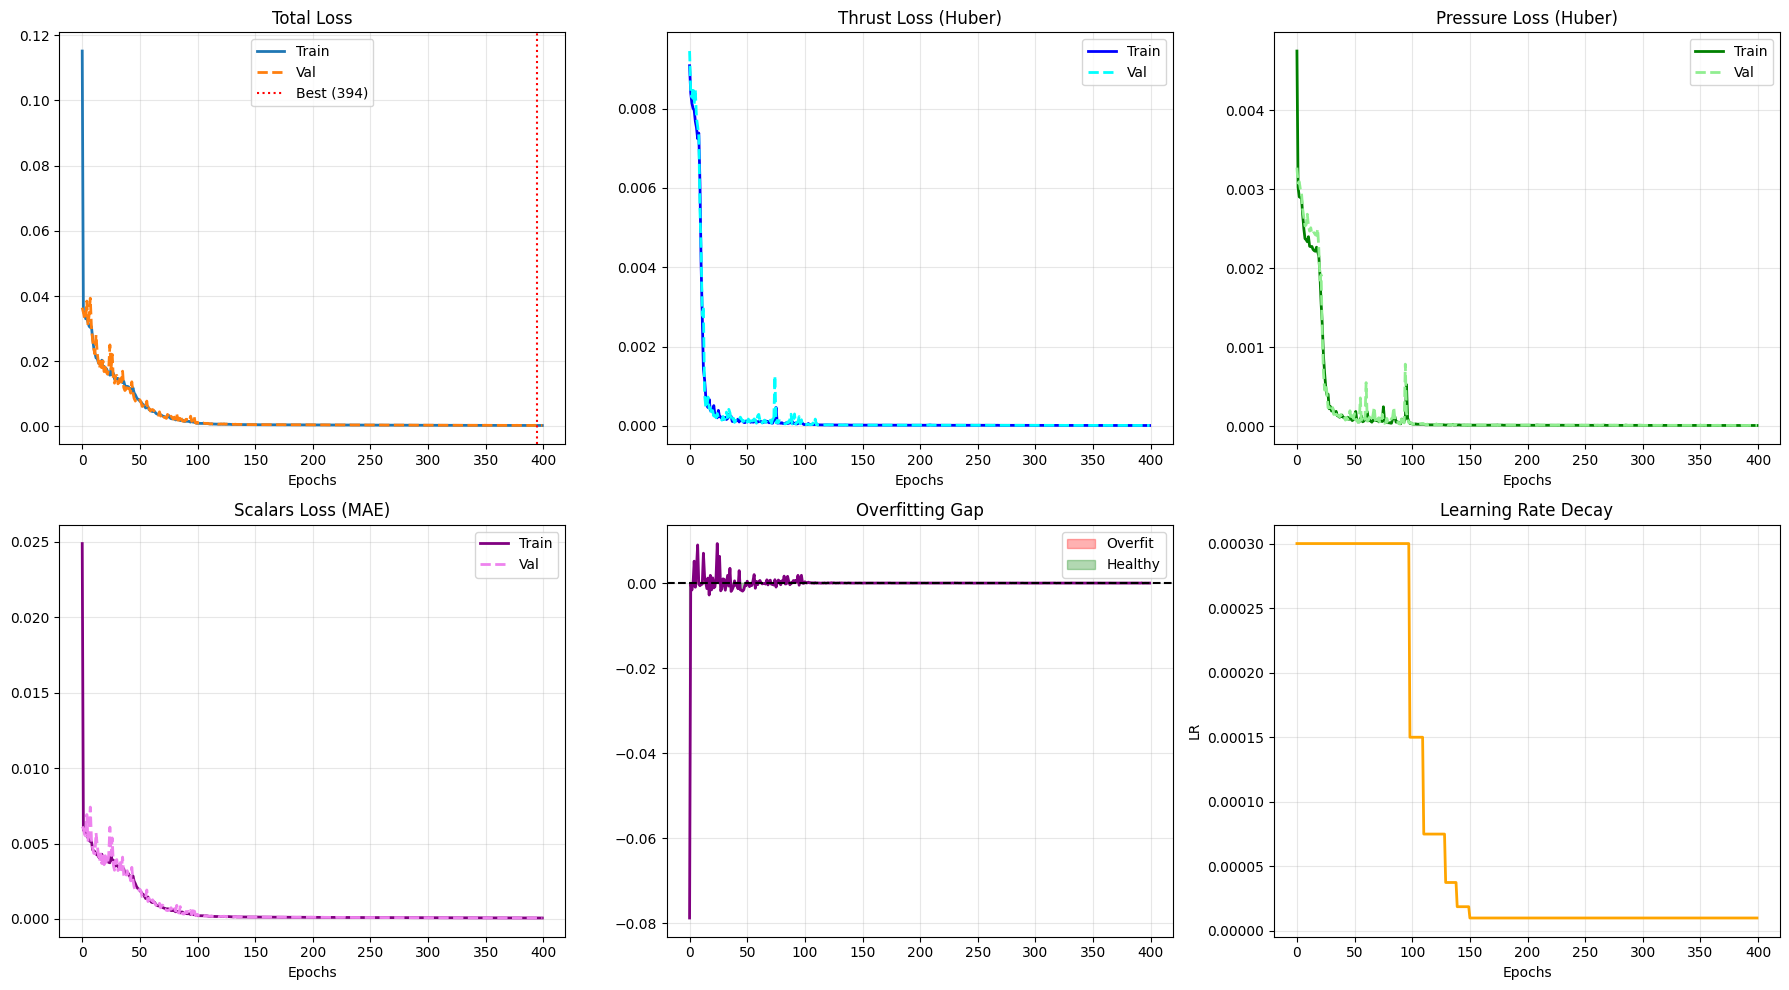

In [60]:
# ===================================================================
# 6. Training Curves for Moon Forward Model
# ===================================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
best_ep = np.argmin(history_fwd.history['val_loss'])

# 1. Total Loss
ax = axes[0, 0]
ax.plot(history_fwd.history['loss'],     label='Train', linewidth=2)
ax.plot(history_fwd.history['val_loss'], label='Val',   linewidth=2, linestyle='--')
ax.axvline(best_ep, color='red', linestyle=':', label=f'Best ({best_ep})')
ax.set_title('Total Loss'); ax.set_xlabel('Epochs')
ax.legend(); ax.grid(True, alpha=0.3)

# 2. Thrust Loss
ax = axes[0, 1]
ax.plot(history_fwd.history['Thrust_Output_loss'],     label='Train', color='blue',    linewidth=2)
ax.plot(history_fwd.history['val_Thrust_Output_loss'], label='Val',   color='cyan', linewidth=2, linestyle='--')
ax.set_title('Thrust Loss (Huber)'); ax.set_xlabel('Epochs')
ax.legend(); ax.grid(True, alpha=0.3)

# 3. Pressure Loss
ax = axes[0, 2]
ax.plot(history_fwd.history['Pressure_Output_loss'],     label='Train', color='green', linewidth=2)
ax.plot(history_fwd.history['val_Pressure_Output_loss'], label='Val',   color='lightgreen', linewidth=2, linestyle='--')
ax.set_title('Pressure Loss (Huber)'); ax.set_xlabel('Epochs')
ax.legend(); ax.grid(True, alpha=0.3)

# 4. Scalars Loss (ISP, Impulse, BurnTime, MaxThrust)
ax = axes[1, 0]
ax.plot(history_fwd.history['Scalars_Output_loss'],     label='Train', color='purple', linewidth=2)
ax.plot(history_fwd.history['val_Scalars_Output_loss'], label='Val',   color='violet', linewidth=2, linestyle='--')
ax.set_title('Scalars Loss (MAE)'); ax.set_xlabel('Epochs')
ax.legend(); ax.grid(True, alpha=0.3)

# 5. Overfitting Gap
ax = axes[1, 1]
gap = np.array(history_fwd.history['val_loss']) - np.array(history_fwd.history['loss'])
ax.plot(gap, color='purple', linewidth=2)
ax.axhline(0, color='black', linestyle='--')
ax.fill_between(range(len(gap)), gap, 0,
                where=(gap > 0), alpha=0.3, color='red',   label='Overfit')
ax.fill_between(range(len(gap)), gap, 0,
                where=(gap < 0), alpha=0.3, color='green', label='Healthy')
ax.set_title('Overfitting Gap')
ax.legend(); ax.grid(True, alpha=0.3)

# 6. Learning Rate Decay (متابعة تناقص معدل التعلم)
ax = axes[1, 2]
if 'learning_rate' in history_fwd.history:
    ax.plot(history_fwd.history['learning_rate'], color='orange', linewidth=2)
    ax.set_title('Learning Rate Decay')
    ax.set_xlabel('Epochs')
    ax.set_ylabel('LR')
    ax.grid(True, alpha=0.3)
else:
    ax.axis('off') # إخفاء المربع إذا لم يكن معدل التعلم متاحاً

plt.tight_layout()
plt.show()


   Co Grain - Performance Predictor (ReLU Edition)


Length (cm):                130
Diameter (cm):              25
Slot_Width (cm):            6
Slot_Offest (cm):           7.5
Throat Diameter (cm):       4
Exit Diameter (cm):         6


Raw Curve Impulse : 210135.01 N.s

---------------------------------------------
   Predicted Performance (Co Grain)
---------------------------------------------
  ISP                    : 162.24 s
  Burn Time              : 50.55 s
  Max Thrust             : 4628.90 N
  Total Impulse          : 210135.01 N.s
---------------------------------------------


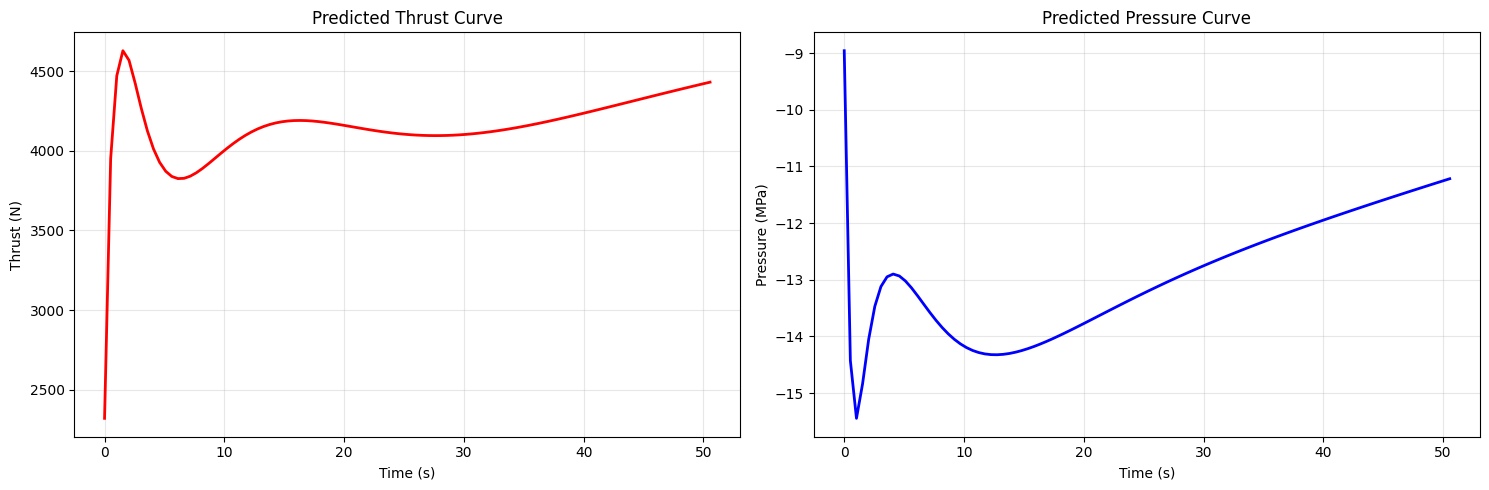

In [64]:
# ===================================================================
# 7. Prediction Function for Moon Forward Model (Clean Curve)
# ===================================================================
def get_user_input_and_predict_c():
    print('\n' + '='*55)
    print('   Co Grain - Performance Predictor (ReLU Edition)')
    print('='*55)
    try:
        l_val  = float(input('Length (cm):               '))
        od_val = float(input('Diameter (cm):             '))
        id_val = float(input('Slot_Width (cm):           '))
        co_val = float(input('Slot_Offest (cm):          ')) 
        td_val = float(input('Throat Diameter (cm):      '))
        ed_val = float(input('Exit Diameter (cm):        '))

        user_inputs        = np.array([[l_val, od_val, id_val, co_val, td_val, ed_val]])
        user_inputs_scaled = s_X.transform(user_inputs)

        preds = moon_forward.predict(user_inputs_scaled, verbose=0)

        max_vals = joblib.load('co_fwd_max_values.pkl')
        yt_max = max_vals['yt_max']
        yp_max = max_vals['yp_max']

        # استخراج المنحنيات
        thrust_pred   = preds[0][0] * yt_max
        pressure_pred = preds[1][0] * yp_max
        
        # استخراج القيم الثابتة
        scalars_pred  = s_ys.inverse_transform(preds[2])[0]

        isp       = max(scalars_pred[0], 1e-9)
        burn_time = max(scalars_pred[1], 1e-9)

        time_steps = np.linspace(0, burn_time, 100)
        
        raw_impulse = np.trapezoid(thrust_pred, time_steps)

        print(f'Raw Curve Impulse : {raw_impulse:.2f} N.s')

        # تنعيم خفيف للمنحنى بدون التأثير على القمة
        #smoothed_thrust   = np.clip(savgol_filter(thrust_pred, window_length=7, polyorder=2), 0, None)
        #smoothed_pressure = np.clip(savgol_filter(pressure_pred, window_length=7, polyorder=2), 0, None)
        smoothed_thrust   = thrust_pred.copy()
        smoothed_pressure = pressure_pred.copy()

        # إغلاق ذيل المنحنى
        # peak_idx = np.argmax(smoothed_thrust)
        # tail     = smoothed_thrust[peak_idx:]
        # cutoff   = np.argmax(tail < 0.02 * smoothed_thrust.max())
        # if cutoff > 0:
        #     smoothed_thrust[peak_idx + cutoff:] = 0
        #     smoothed_pressure[peak_idx + cutoff:] = 0

        # حساب المساحة من المنحنى النهائي
        #predicted_impulse = scalars_pred[1]
        final_max_thrust = np.max(thrust_pred)
        calculated_impulse = np.trapezoid(thrust_pred, time_steps)

        print('\n' + '-'*45)
        print('   Predicted Performance (Co Grain)')
        print('-'*45)
        print(f'  ISP                    : {isp:.2f} s')
        print(f'  Burn Time              : {burn_time:.2f} s')
        
        print(f'  Max Thrust             : {final_max_thrust:.2f} N')
        print(f'  Total Impulse          : {calculated_impulse:.2f} N.s')
        print('-'*45)

        fig, axes = plt.subplots(1, 2, figsize=(15, 5))

        axes[0].plot(time_steps, smoothed_thrust, color='red', linewidth=2)
        axes[0].set_title('Predicted Thrust Curve')
        axes[0].set_xlabel('Time (s)'); axes[0].set_ylabel('Thrust (N)')
        axes[0].grid(True, alpha=0.3)

        axes[1].plot(time_steps, smoothed_pressure, color='blue', linewidth=2)
        axes[1].set_title('Predicted Pressure Curve')
        axes[1].set_xlabel('Time (s)'); axes[1].set_ylabel('Pressure (MPa)')
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    except ValueError:
        print('\n[Error]: Please enter valid numeric values.')
    except Exception as e:
        print(f'\n[Error]: {e}')

get_user_input_and_predict_c()